## WEEK 3 ASSIGNMENT


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [5]:
def development_category(gdpp):
    if gdpp < 2000:
        return 0   # Low development
    elif gdpp < 12000:
        return 1   # Medium development
    else:
        return 2   # High development

df["category"] = df["gdpp"].apply(development_category)
df["category"].value_counts()

,count
category,
1,68
2,50
0,49


In [6]:
# Since no predefined target variable was available, GDP per capita was used to create three development categories: low, medium, and high.

In [7]:
X = df.drop(["country", "category"], axis=1)
y = df["category"]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# Random Forest model

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [12]:
# XGBoost model

In [13]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       1.00      0.86      0.92        14
           2       1.00      1.00      1.00        10

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.95      0.94      0.94        34



In [14]:
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
8,gdpp,0.433606
4,income,0.258925
0,child_mort,0.127564
6,life_expec,0.064357
7,total_fer,0.048344
1,exports,0.023484
5,inflation,0.022912
2,health,0.011079
3,imports,0.009729


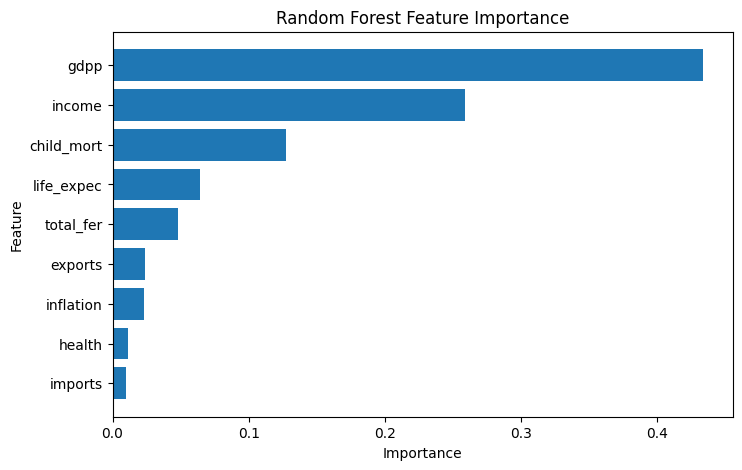

In [16]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

#### Income, GDP per capita, child mortality, and life expectancy were the most influential factors in predicting the development category.

In [17]:
# K-Means clustering

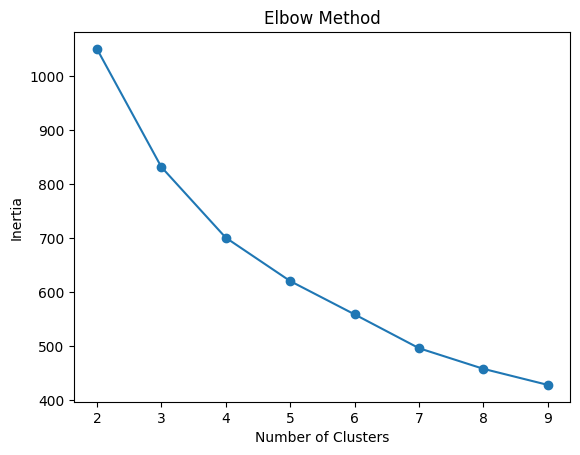

In [18]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [19]:
# Choose k =3

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

df[["country", "KMeans_Cluster"]].head()

,country,KMeans_Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


In [21]:
cluster_summary = df.groupby("KMeans_Cluster")[X.columns].mean()
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [22]:
# K-Means clustering identified three distinct country segments.

# Cluster 0 represents highly developed countries with the highest income and GDP per capita, low child mortality, and high life expectancy.

# Cluster 1 represents underdeveloped countries characterized by low income levels, low GDP per capita, high child mortality, and lower life expectancy. These countries may require targeted economic and healthcare interventions.

# Cluster 2 represents developing countries with moderate economic and health indicators. These countries show better performance than Cluster 1 but have not yet reached the development levels of Cluster 0.

# The clustering results provide actionable insights for identifying countries with similar socio-economic characteristics and support data-driven policy planning.

In [29]:
score = silhouette_score(X_scaled, df["KMeans_Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.28329575683463126


In [23]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,161
-1,6


In [30]:
# DBSCAN identified 6 countries as outliers with unusually high or low socio-economic indicators.

In [24]:
df[df["DBSCAN_Cluster"] == -1][["country", "gdpp", "income", "child_mort"]]

,country,gdpp,income,child_mort
66,Haiti,662,1500,208.0
91,Luxembourg,105000,91700,2.8
98,Malta,21100,28300,6.8
113,Nigeria,2330,5150,130.0
123,Qatar,70300,125000,9.0
133,Singapore,46600,72100,2.8


In [25]:
# DBSCAN helped identify outlier countries that do not fit into normal development groups.

In [26]:
df[["country", "category", "KMeans_Cluster", "DBSCAN_Cluster"]].head(20)

,country,category,KMeans_Cluster,DBSCAN_Cluster
0,Afghanistan,0,1,0
1,Albania,1,2,0
2,Algeria,1,2,0
3,Angola,1,1,0
4,Antigua and Barbuda,2,2,0
5,Argentina,1,2,0
6,Armenia,1,2,0
7,Australia,2,0,0
8,Austria,2,0,0
9,Azerbaijan,1,2,0


In [28]:
# In this assignment, an end-to-end Customer Intelligence System was developed using classification, ensemble learning, and clustering techniques. Random Forest and XGBoost were used to classify countries into development categories based on economic and health indicators. K-Means clustering was applied to segment countries into meaningful groups, while DBSCAN helped detect outliers. The system provided actionable insights by identifying high-risk countries with low income, high child mortality, and low life expectancy, which can help in targeted decision-making and resource allocation.